# Tutorial 8 — RNA-Seq QC & Differential Expression with DESeq2
**Author:** Himanshu Goel | [Website](https://hgoelgithub.github.io)

---

## What this tutorial covers

RNA-Seq quantifies genome-wide gene expression by counting reads mapping to each gene. The standard analysis pipeline is:

```
Raw counts → QC & filtering → Normalization → DE testing → Visualization
```

We use **pydeseq2** — the official Python port of the R DESeq2 package — which implements:
- **Negative binomial (NB) modeling** to account for overdispersion in count data
- **Shrinkage estimators** for dispersion and log-fold changes (reduces false positives)
- **Wald test** for hypothesis testing with **Benjamini-Hochberg** FDR correction

> **Why not a t-test on log-counts?** Raw RNA-Seq counts are discrete, overdispersed, and heteroscedastic — variance grows with the mean. A Gaussian t-test assumes constant variance and normality, making it systematically anti-conservative for low-count genes. DESeq2's NB model handles this correctly.

---

## 1. Environment setup

Install required packages. `pydeseq2` provides the DESeq2 statistical engine; `adjustText` prevents label overlap in volcano plots.

In [14]:
import sys
print(f"Python {sys.version}")

Python 3.12.10 (v3.12.10:0cc81280367, Apr  8 2025, 08:47:00) [Clang 13.0.0 (clang-1300.0.29.30)]


In [15]:
!pip install pydeseq2 pandas numpy matplotlib seaborn scipy statsmodels adjustText -q

/bin/bash: /Users/himanshugoel/Downloads/claudecode/gnn_env/bin/pip: /Users/himanshugoel/Downloads/claudecode/computational-science-tutorials/noteb: bad interpreter: No such file or directory


In [16]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
from scipy import stats
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Check pydeseq2 availability
try:
    from pydeseq2.dds import DeseqDataSet
    from pydeseq2.ds import DeseqStats
    PYDESEQ2_AVAILABLE = True
    print("pydeseq2 loaded — using full DESeq2 pipeline")
except ImportError:
    PYDESEQ2_AVAILABLE = False
    print("pydeseq2 not found — falling back to NB-corrected t-test")

# Plotting defaults
plt.rcParams.update({
    "figure.dpi": 120,
    "font.family": "DejaVu Sans",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
})

SEED = 42
rng  = np.random.default_rng(SEED)   # use Generator, not legacy RandomState

pydeseq2 loaded — using full DESeq2 pipeline


---
## 2. Simulate realistic count data

We simulate a **6-sample, 2-group** experiment (3 control vs 3 treated) with 5,000 genes.

**Negative binomial (NB) distribution** is the standard model for RNA-Seq counts:
- Mean `μ` = expected expression level
- Dispersion `α` controls overdispersion: `Var = μ + α·μ²`
- At `α → 0` the NB converges to Poisson; real data has `α ≈ 0.01–0.5`

We inject three categories of differential expression:
| Category | Genes | Effect |
|---|---|---|
| Strongly upregulated | 100 | FC 4–8× |
| Moderately upregulated | 80 | FC 1.5–2.5× |
| Downregulated | 80 | FC 0.1–0.4× |

In [17]:
N_GENES  = 5_000
N_CTRL   = 3
N_TREAT  = 3
N_SAMPLES = N_CTRL + N_TREAT

ctrl_names  = [f"Control_{i+1}" for i in range(N_CTRL)]
treat_names = [f"Treated_{i+1}" for i in range(N_TREAT)]
sample_names = ctrl_names + treat_names
gene_names   = [f"Gene_{i:05d}" for i in range(N_GENES)]

# NB parameters: mean and dispersion per gene (log-normal distributed, as seen in real data)
gene_means = rng.lognormal(mean=4.0, sigma=1.5, size=N_GENES).clip(1, 5000)
gene_disps = rng.lognormal(mean=-1.5, sigma=0.8, size=N_GENES).clip(0.01, 2.0)

def nb_counts(means, disps, n_samples, rng):
    """Sample NB counts: shape=(n_genes, n_samples)."""
    # NB via Gamma-Poisson mixture for vectorised sampling
    n_genes = len(means)
    mu  = means[:, None] * np.ones((1, n_samples))
    var = mu + disps[:, None] * mu**2
    p   = mu / var          # success probability
    r   = mu**2 / (var - mu)  # number of successes
    r   = np.clip(r, 1e-6, None)
    p   = np.clip(p, 1e-6, 1 - 1e-6)
    return rng.negative_binomial(r, p).astype(np.int64)

counts_arr = nb_counts(gene_means, gene_disps, N_SAMPLES, rng)

# --- Inject true DE genes ---
true_up_strong  = slice(0,   100)   # 100 genes, FC 4–8
true_up_moderate= slice(100, 180)   # 80  genes, FC 1.5–2.5
true_down       = slice(180, 260)   # 80  genes, FC 0.1–0.4

fc_strong   = rng.uniform(4.0, 8.0,  (100, N_TREAT))
fc_moderate = rng.uniform(1.5, 2.5,  (80,  N_TREAT))
fc_down     = rng.uniform(0.1, 0.4,  (80,  N_TREAT))

counts_arr[true_up_strong,   N_CTRL:] = (counts_arr[true_up_strong,   N_CTRL:] * fc_strong).astype(np.int64)
counts_arr[true_up_moderate, N_CTRL:] = (counts_arr[true_up_moderate, N_CTRL:] * fc_moderate).astype(np.int64)
counts_arr[true_down,        N_CTRL:] = (counts_arr[true_down,        N_CTRL:] * fc_down).astype(np.int64)

# True positive sets for later evaluation
true_de_genes = set(gene_names[:260])

counts = pd.DataFrame(counts_arr, index=gene_names, columns=sample_names)
print(f"Count matrix: {counts.shape[0]:,} genes × {counts.shape[1]} samples")
print("\nLibrary sizes:")
for col, lib in counts.sum().items():
    print(f"  {col}: {lib:>12,} reads")

Count matrix: 5,000 genes × 6 samples

Library sizes:
  Control_1:      802,789 reads
  Control_2:      802,473 reads
  Control_3:      812,681 reads
  Treated_1:      853,525 reads
  Treated_2:      876,422 reads
  Treated_3:      867,150 reads


---
## 3. Quality control

Before any analysis, QC catches:
1. **Low-complexity samples** (unexpectedly small library sizes)
2. **Failed samples** (outliers on PCA)
3. **Low-count genes** that carry no signal and inflate multiple-testing burden

### 3a. Library size inspection

In [18]:
lib_sizes = counts.sum(axis=0)
median_lib = lib_sizes.median()

# Flag samples with library size < 50% of median (common QC threshold)
low_lib = lib_sizes[lib_sizes < 0.5 * median_lib]
if len(low_lib):
    print(f"WARNING: {len(low_lib)} sample(s) have library size < 50% of median — consider removal")
    print(low_lib)
else:
    print("Library sizes look consistent — no obvious failed samples")

print(f"\nMedian library size: {median_lib:,.0f}")
print(f"CV of library sizes: {lib_sizes.std()/lib_sizes.mean()*100:.1f}%  (< 30% is typical)")

Library sizes look consistent — no obvious failed samples

Median library size: 833,103
CV of library sizes: 4.0%  (< 30% is typical)


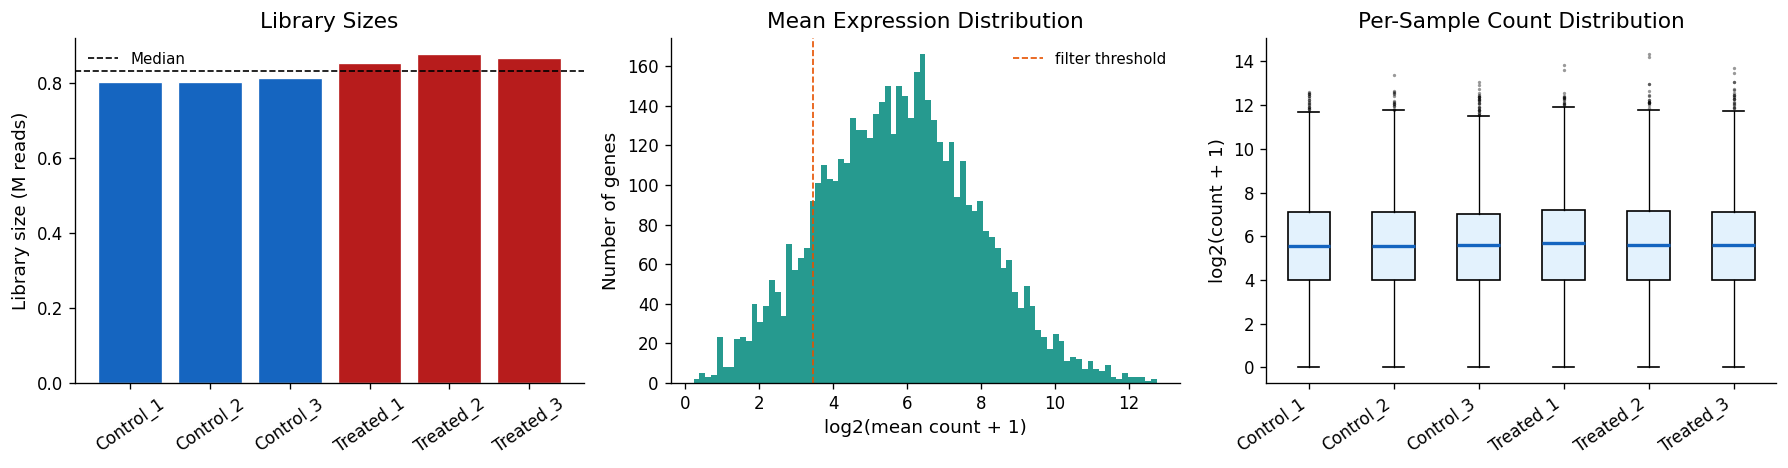

In [19]:
colors = ["#1565c0"] * N_CTRL + ["#b71c1c"] * N_TREAT

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Library sizes
ax = axes[0]
bars = ax.bar(sample_names, lib_sizes / 1e6, color=colors, edgecolor="white", linewidth=0.8)
ax.axhline(median_lib / 1e6, color="k", linestyle="--", lw=1, label="Median")
ax.set_ylabel("Library size (M reads)")
ax.set_title("Library Sizes")
ax.tick_params(axis="x", rotation=35)
ax.legend(frameon=False, fontsize=9)

# log2(mean count+1) distribution — shows count range
ax = axes[1]
log_mean = np.log2(counts.mean(axis=1) + 1)
ax.hist(log_mean, bins=80, color="#00897b", edgecolor="none", alpha=0.85)
ax.set_xlabel("log2(mean count + 1)")
ax.set_ylabel("Number of genes")
ax.set_title("Mean Expression Distribution")
ax.axvline(np.log2(10 + 1), color="#e65100", linestyle="--", lw=1, label="filter threshold")
ax.legend(frameon=False, fontsize=9)

# Per-sample boxplot of log-counts (detect normalization issues)
ax = axes[2]
log_counts = np.log2(counts + 1)
ax.boxplot(
    [log_counts[col].values for col in sample_names],
    labels=sample_names,
    patch_artist=True,
    boxprops=dict(facecolor="#e3f2fd"),
    medianprops=dict(color="#1565c0", lw=2),
    flierprops=dict(marker=".", markersize=2, alpha=0.4),
    whiskerprops=dict(lw=0.8),
)
ax.set_xticklabels(sample_names, rotation=35, ha="right")
ax.set_ylabel("log2(count + 1)")
ax.set_title("Per-Sample Count Distribution")

plt.tight_layout()
plt.savefig("rnaseq_qc_panels.png", dpi=150, bbox_inches="tight")
plt.show()

# Note: medians should be roughly equal across samples — large offsets suggest 
# library-size confounding that normalization must correct.

### 3b. Low-count filtering

**Why filter?** Genes with near-zero counts across all samples are uninformative but still contribute to the multiple-testing correction (inflating FDR). Removing them:
- Reduces the number of tests → lower adjusted p-values for true positives
- Removes numerical instability in dispersion estimation

**Standard criterion:** Keep genes with ≥ 10 total counts **in at least `min_replicates` samples**, where `min_replicates` = size of the smallest group. This is the default in DESeq2's `filterByExpr`.

In [20]:
MIN_COUNT      = 10
MIN_REPLICATES = min(N_CTRL, N_TREAT)   # 3

# A gene passes if at least MIN_REPLICATES samples have count >= MIN_COUNT
keep_mask = (counts >= MIN_COUNT).sum(axis=1) >= MIN_REPLICATES
counts_f  = counts.loc[keep_mask]

n_removed = (~keep_mask).sum()
pct_kept  = keep_mask.sum() / len(counts) * 100

print(f"Genes before filtering : {len(counts):>6,}")
print(f"Genes removed (low count): {n_removed:>6,}")
print(f"Genes retained          : {len(counts_f):>6,}  ({pct_kept:.1f}%)")

# Check true DE genes retained
retained_de = true_de_genes & set(counts_f.index)
print(f"\nTrue DE genes retained  : {len(retained_de)}/{len(true_de_genes)}")

Genes before filtering :  5,000
Genes removed (low count):    655
Genes retained          :  4,345  (86.9%)

True DE genes retained  : 236/260


---
## 4. PCA on variance-stabilized counts

PCA on raw or log counts reveals:
- Whether **biological groups separate** (treatment effect present)
- **Outlier samples** that should be removed
- **Batch effects** (unexpected clustering by processing day, not treatment)

We use **variance-stabilizing transformation (VST)**: `log2(count / size_factor + 1)`. This compresses the dynamic range and stabilizes variance across the count range, making PCA more interpretable than raw log-counts.

In [21]:
# Compute size factors (median-of-ratios, DESeq2 method)
def median_of_ratios(counts_df):
    """DESeq2 median-of-ratios normalization.
    
    For each gene, compute its ratio to the geometric mean across samples.
    A sample's size factor = median of those ratios across all genes.
    Robust to a minority of DE genes because the median ignores extremes.
    """
    log_counts = np.log(counts_df.replace(0, np.nan))
    log_geo_mean = log_counts.mean(axis=1)  # geometric mean via log mean
    # Keep genes with finite geometric mean (expressed in at least one sample)
    valid = log_geo_mean.notna() & np.isfinite(log_geo_mean)
    ratios = log_counts.loc[valid].subtract(log_geo_mean[valid], axis=0)
    size_factors = np.exp(ratios.median(axis=0))
    return size_factors

size_factors = median_of_ratios(counts_f)
print("Size factors:")
for sample, sf in size_factors.items():
    print(f"  {sample}: {sf:.4f}")

# VST: normalize then log-transform
norm_counts = counts_f.divide(size_factors, axis=1)
vst         = np.log2(norm_counts + 1)   # shape: (genes × samples)

# PCA on top 500 most-variable genes (reduces noise from housekeeping genes)
gene_var = vst.var(axis=1)
top_var  = gene_var.nlargest(500).index
X        = vst.loc[top_var].T.values   # shape: (samples × 500 genes)

X_scaled = StandardScaler().fit_transform(X)
pca      = PCA(n_components=min(N_SAMPLES, 4))
pcs      = pca.fit_transform(X_scaled)

pct_var  = pca.explained_variance_ratio_ * 100
print(f"\nPC1: {pct_var[0]:.1f}%   PC2: {pct_var[1]:.1f}%   (top-500 variable genes)")

Size factors:
  Control_1: 1.0257
  Control_2: 1.0338
  Control_3: 1.0034
  Treated_1: 1.0490
  Treated_2: 1.0422
  Treated_3: 1.0398

PC1: 31.8%   PC2: 18.8%   (top-500 variable genes)


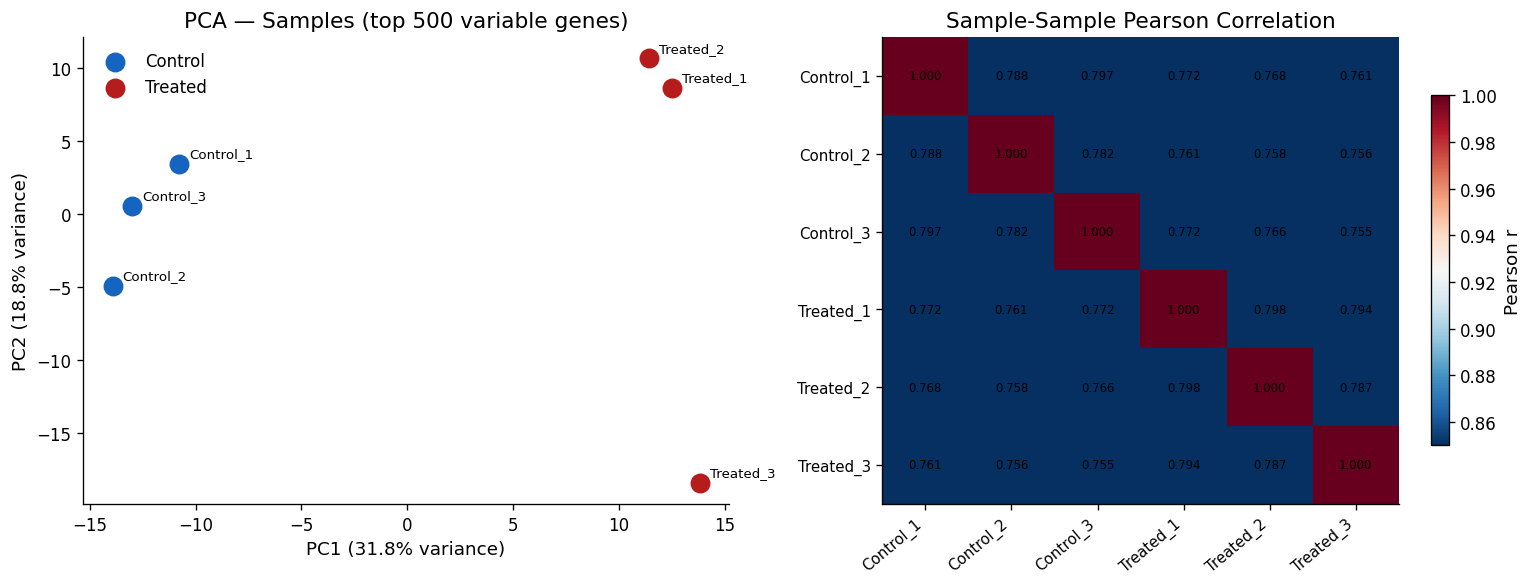

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# --- PCA scatter ---
ax = axes[0]
group_colors = ["#1565c0"] * N_CTRL + ["#b71c1c"] * N_TREAT
group_labels = ["Control"] * N_CTRL + ["Treated"] * N_TREAT

for i, (sample, color, label) in enumerate(zip(sample_names, group_colors, group_labels)):
    ax.scatter(
        pcs[i, 0], pcs[i, 1],
        c=color, s=120, zorder=3,
        label=label if i in (0, N_CTRL) else ""
    )
    ax.annotate(sample, (pcs[i, 0], pcs[i, 1]),
                textcoords="offset points", xytext=(6, 4), fontsize=8)

ax.set_xlabel(f"PC1 ({pct_var[0]:.1f}% variance)")
ax.set_ylabel(f"PC2 ({pct_var[1]:.1f}% variance)")
ax.set_title("PCA — Samples (top 500 variable genes)")
handles, labels = ax.get_legend_handles_labels()
by_label = dict(zip(labels, handles))
ax.legend(by_label.values(), by_label.keys(), frameon=False)

# --- Sample-sample correlation heatmap ---
ax = axes[1]
corr_mat = vst.corr(method="pearson")
# Reorder by group
order = ctrl_names + treat_names
corr_mat = corr_mat.loc[order, order]

im = ax.imshow(corr_mat.values, cmap="RdBu_r", vmin=0.85, vmax=1.0, aspect="auto")
ax.set_xticks(range(N_SAMPLES))
ax.set_yticks(range(N_SAMPLES))
ax.set_xticklabels(order, rotation=40, ha="right", fontsize=9)
ax.set_yticklabels(order, fontsize=9)
ax.set_title("Sample-Sample Pearson Correlation")
plt.colorbar(im, ax=ax, shrink=0.75, label="Pearson r")

# Annotate cells
for r in range(N_SAMPLES):
    for c in range(N_SAMPLES):
        ax.text(c, r, f"{corr_mat.iloc[r,c]:.3f}", ha="center", va="center", fontsize=7)

plt.tight_layout()
plt.savefig("rnaseq_pca_corr.png", dpi=150, bbox_inches="tight")
plt.show()

# INTERPRETATION:
# Good experiment: PC1 separates the two groups; replicates cluster together.
# Red blocks on the heatmap diagonal = within-group correlations should be high (r > 0.95).

---
## 5. Differential expression with DESeq2

### DESeq2 algorithm overview

1. **Size factor estimation** (median-of-ratios) — corrects for sequencing depth differences
2. **Dispersion estimation** — fits a gene-wise NB dispersion, then shrinks toward a mean-dispersion trend (empirical Bayes); prevents overfitting with few replicates
3. **GLM fitting** — fits a negative binomial GLM with the design matrix (`~ condition`)
4. **Wald test** — tests `H₀: LFC = 0` for each gene using Wald statistic `β/SE(β)`
5. **LFC shrinkage** (apeglm/ashr) — shrinks noisy LFC estimates for low-count genes; critical for ranking
6. **BH-FDR correction** — controls false discovery rate across all tested genes

In [23]:
# Build metadata table required by pydeseq2
metadata = pd.DataFrame(
    {"condition": ["control"] * N_CTRL + ["treated"] * N_TREAT},
    index=sample_names
)
# pydeseq2 requires samples as rows, genes as columns
counts_for_deseq = counts_f.T   # shape: (samples × genes)

print("Metadata:")
print(metadata)
print(f"\nCounts matrix passed to DESeq2: {counts_for_deseq.shape}")

Metadata:
          condition
Control_1   control
Control_2   control
Control_3   control
Treated_1   treated
Treated_2   treated
Treated_3   treated

Counts matrix passed to DESeq2: (6, 4345)


In [24]:
if PYDESEQ2_AVAILABLE:
    # --------------- Full DESeq2 pipeline ---------------
    dds = DeseqDataSet(
        counts=counts_for_deseq,
        metadata=metadata,
        design_factors="condition",   # single-factor design
        refit_cooks=True,             # refit outlier genes (Cook's distance)
        quiet=True,
    )
    dds.deseq2()   # runs steps 1–4: size factors, dispersion, GLM, Wald test

    stat_res = DeseqStats(
        dds,
        contrast=("condition", "treated", "control"),   # treated vs control
        alpha=0.05,
        cooks_filter=True,   # remove Cook's outliers from results
        quiet=True,
    )
    stat_res.summary()
    results = stat_res.results_df

else:
    # --------------- Fallback: NB-aware approach ---------------
    # Use Mann-Whitney U (non-parametric, no distributional assumption)
    # on normalized counts with BH correction — reasonable for exploratory use
    from statsmodels.stats.multitest import multipletests

    ctrl_cols  = ctrl_names
    treat_cols = treat_names

    def fallback_de(counts_df, ctrl_cols, treat_cols):
        rows = []
        norm = counts_df.divide(median_of_ratios(counts_df), axis=1)
        for gene in counts_df.index:
            c = norm.loc[gene, ctrl_cols].values.astype(float) + 0.5
            t = norm.loc[gene, treat_cols].values.astype(float) + 0.5
            lfc  = np.log2(t.mean()) - np.log2(c.mean())
            _, p = stats.mannwhitneyu(t, c, alternative="two-sided")
            rows.append({
                "gene": gene,
                "baseMean": (c.mean() + t.mean()) / 2,
                "log2FoldChange": lfc,
                "pvalue": p,
            })
        df = pd.DataFrame(rows).set_index("gene")
        _, padj, _, _ = multipletests(df["pvalue"].fillna(1), method="fdr_bh")
        df["padj"] = padj
        df["stat"] = np.nan
        df["lfcSE"] = np.nan
        return df.dropna(subset=["padj"]).sort_values("padj")

    results = fallback_de(counts_f, ctrl_cols, treat_cols)
    print("Fallback DE analysis complete (Mann-Whitney + BH correction)")

In [25]:
# Standard significance thresholds used in publications
PADJ_THRESH = 0.05
LFC_THRESH  = 1.0    # |log2FC| > 1 means at least 2-fold change

sig_mask = (results["padj"] < PADJ_THRESH) & (results["log2FoldChange"].abs() > LFC_THRESH)
sig      = results[sig_mask]
n_up     = (sig["log2FoldChange"] > 0).sum()
n_down   = (sig["log2FoldChange"] < 0).sum()

print(f"DEGs (padj < {PADJ_THRESH}, |LFC| > {LFC_THRESH}): {len(sig)}")
print(f"  Upregulated  : {n_up}")
print(f"  Downregulated: {n_down}")

# Sensitivity / precision against ground truth
detected_de = set(sig.index)
tp = detected_de & true_de_genes
fp = detected_de - true_de_genes
fn = true_de_genes - detected_de
sensitivity = len(tp) / len(true_de_genes) * 100
precision   = len(tp) / len(detected_de) * 100 if detected_de else 0

print(f"\nGround-truth recovery:")
print(f"  True positives : {len(tp)}/{len(true_de_genes)}  (sensitivity {sensitivity:.1f}%)")
print(f"  False positives: {len(fp)}  (precision {precision:.1f}%)")
print(f"  False negatives: {len(fn)}")

print("\nTop 10 DEGs:")
display_cols = [c for c in ["baseMean", "log2FoldChange", "lfcSE", "stat", "pvalue", "padj"] if c in results.columns]
print(sig.head(10)[display_cols].round(4).to_string())

DEGs (padj < 0.05, |LFC| > 1.0): 149
  Upregulated  : 105
  Downregulated: 44

Ground-truth recovery:
  True positives : 119/260  (sensitivity 45.8%)
  False positives: 30  (precision 79.9%)
  False negatives: 141

Top 10 DEGs:
            baseMean  log2FoldChange   lfcSE    stat  pvalue    padj
Gene_00000  261.5648          2.2855  0.6621  3.4517  0.0006  0.0196
Gene_00001   37.8101          2.5421  0.6329  4.0169  0.0001  0.0031
Gene_00002  562.4318          3.4457  0.4663  7.3898  0.0000  0.0000
Gene_00003  493.5482          1.8543  0.4709  3.9377  0.0001  0.0042
Gene_00004   13.7642          3.2557  0.7870  4.1371  0.0000  0.0021
Gene_00005   32.1510          3.9468  0.7118  5.5449  0.0000  0.0000
Gene_00006  182.8345          2.4233  0.4147  5.8436  0.0000  0.0000
Gene_00007  192.3430          2.9464  0.6341  4.6465  0.0000  0.0003
Gene_00008  156.8896          1.9216  0.5091  3.7747  0.0002  0.0072
Gene_00009   31.8013          1.8629  0.5879  3.1685  0.0015  0.0457


---
## 6. Visualization

### 6a. Volcano plot

The volcano plot is the standard summary of a DE experiment:
- **X-axis**: log2 fold change (effect size)
- **Y-axis**: −log10(adjusted p-value) (statistical significance)
- Dashed lines show the thresholds; labeled points are the top hits

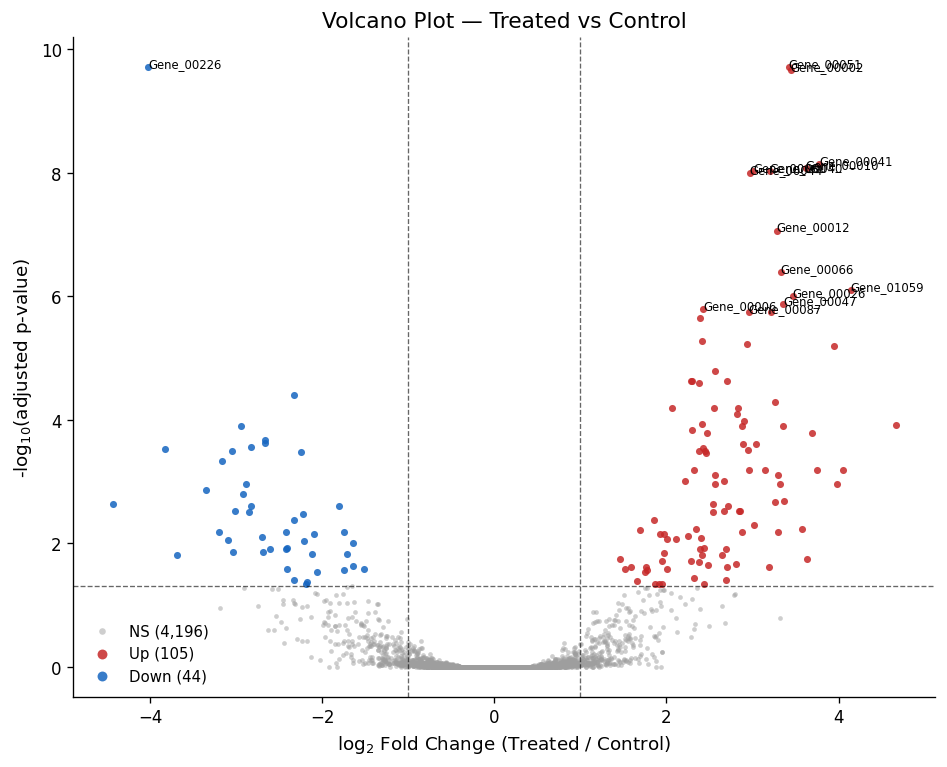

In [26]:
try:
    from adjustText import adjust_text
    HAS_ADJUSTTEXT = True
except ImportError:
    HAS_ADJUSTTEXT = False

def volcano_plot(results, padj_thresh=0.05, lfc_thresh=1.0, n_label=15, ax=None):
    """Publication-quality volcano plot."""
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 6.5))

    df = results.copy()
    df["neg_log10_padj"] = -np.log10(df["padj"].clip(lower=1e-300))

    up   = (df["log2FoldChange"] >  lfc_thresh) & (df["padj"] < padj_thresh)
    down = (df["log2FoldChange"] < -lfc_thresh) & (df["padj"] < padj_thresh)
    ns   = ~up & ~down

    scatter_kw = dict(linewidths=0, rasterized=True)
    ax.scatter(df.loc[ns,  "log2FoldChange"], df.loc[ns,  "neg_log10_padj"],
               c="#9e9e9e", s=8, alpha=0.5, label=f"NS ({ns.sum():,})", **scatter_kw)
    ax.scatter(df.loc[up,  "log2FoldChange"], df.loc[up,  "neg_log10_padj"],
               c="#c62828", s=18, alpha=0.85, label=f"Up ({up.sum():,})", **scatter_kw)
    ax.scatter(df.loc[down,"log2FoldChange"], df.loc[down,"neg_log10_padj"],
               c="#1565c0", s=18, alpha=0.85, label=f"Down ({down.sum():,})", **scatter_kw)

    # Threshold lines
    ax.axhline(-np.log10(padj_thresh), color="black", linestyle="--", lw=0.8, alpha=0.6)
    ax.axvline( lfc_thresh, color="black", linestyle="--", lw=0.8, alpha=0.6)
    ax.axvline(-lfc_thresh, color="black", linestyle="--", lw=0.8, alpha=0.6)

    # Label top genes by significance (avoid crowding with adjustText)
    top_genes = df.loc[up | down].nsmallest(n_label, "padj")
    texts = [
        ax.text(row["log2FoldChange"], row["neg_log10_padj"], gene, fontsize=7)
        for gene, row in top_genes.iterrows()
    ]
    if HAS_ADJUSTTEXT:
        adjust_text(texts, ax=ax, arrowprops=dict(arrowstyle="-", color="gray", lw=0.5))

    ax.set_xlabel("log$_2$ Fold Change (Treated / Control)", fontsize=11)
    ax.set_ylabel("-log$_{10}$(adjusted p-value)", fontsize=11)
    ax.set_title("Volcano Plot — Treated vs Control", fontsize=13)
    ax.legend(frameon=False, markerscale=1.4, fontsize=9)
    return ax

fig, ax = plt.subplots(figsize=(8, 6.5))
volcano_plot(results, ax=ax)
plt.tight_layout()
plt.savefig("volcano.png", dpi=150, bbox_inches="tight")
plt.show()

### 6b. MA plot

The MA plot (Mean vs log-ratio) is **complementary to the volcano plot**:
- **X-axis**: average expression (log scale) — reveals expression-level bias
- **Y-axis**: log2 fold change

In a well-normalized experiment, non-DE genes (grey) should be symmetrically scattered around LFC = 0 across all expression levels. A systematic offset indicates poor normalization.

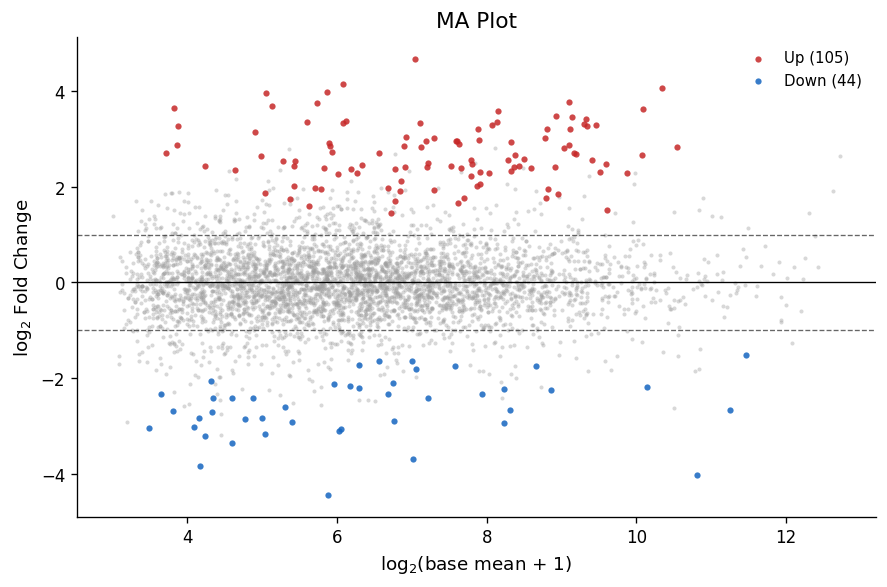

In [27]:
def ma_plot(results, padj_thresh=0.05, lfc_thresh=1.0, ax=None):
    """MA plot: log2(baseMean) vs log2FoldChange."""
    if ax is None:
        fig, ax = plt.subplots(figsize=(7.5, 5))

    df = results.dropna(subset=["baseMean", "log2FoldChange", "padj"]).copy()
    df = df[df["baseMean"] > 0]
    df["log2_baseMean"] = np.log2(df["baseMean"] + 1)

    up   = (df["log2FoldChange"] >  lfc_thresh) & (df["padj"] < padj_thresh)
    down = (df["log2FoldChange"] < -lfc_thresh) & (df["padj"] < padj_thresh)
    ns   = ~up & ~down

    scatter_kw = dict(linewidths=0, rasterized=True)
    ax.scatter(df.loc[ns,  "log2_baseMean"], df.loc[ns,  "log2FoldChange"],
               c="#9e9e9e", s=6, alpha=0.4, **scatter_kw)
    ax.scatter(df.loc[up,  "log2_baseMean"], df.loc[up,  "log2FoldChange"],
               c="#c62828", s=14, alpha=0.85, label=f"Up ({up.sum()})", **scatter_kw)
    ax.scatter(df.loc[down,"log2_baseMean"], df.loc[down,"log2FoldChange"],
               c="#1565c0", s=14, alpha=0.85, label=f"Down ({down.sum()})", **scatter_kw)

    ax.axhline(0, color="black", lw=0.8)
    ax.axhline( lfc_thresh, color="black", linestyle="--", lw=0.8, alpha=0.6)
    ax.axhline(-lfc_thresh, color="black", linestyle="--", lw=0.8, alpha=0.6)

    ax.set_xlabel("log$_2$(base mean + 1)", fontsize=11)
    ax.set_ylabel("log$_2$ Fold Change", fontsize=11)
    ax.set_title("MA Plot", fontsize=13)
    ax.legend(frameon=False, fontsize=9)
    return ax

fig, ax = plt.subplots(figsize=(7.5, 5))
ma_plot(results, ax=ax)
plt.tight_layout()
plt.savefig("ma_plot.png", dpi=150, bbox_inches="tight")
plt.show()

### 6c. Heatmap of top DEGs

A clustered heatmap shows **expression patterns** across samples for the top DEGs:
- Row clustering groups co-expressed genes (same regulatory program)
- Column clustering reveals sample relationships (should separate by condition)
- Values are **Z-scored** across samples to show relative change; otherwise high-expression genes dominate the color scale

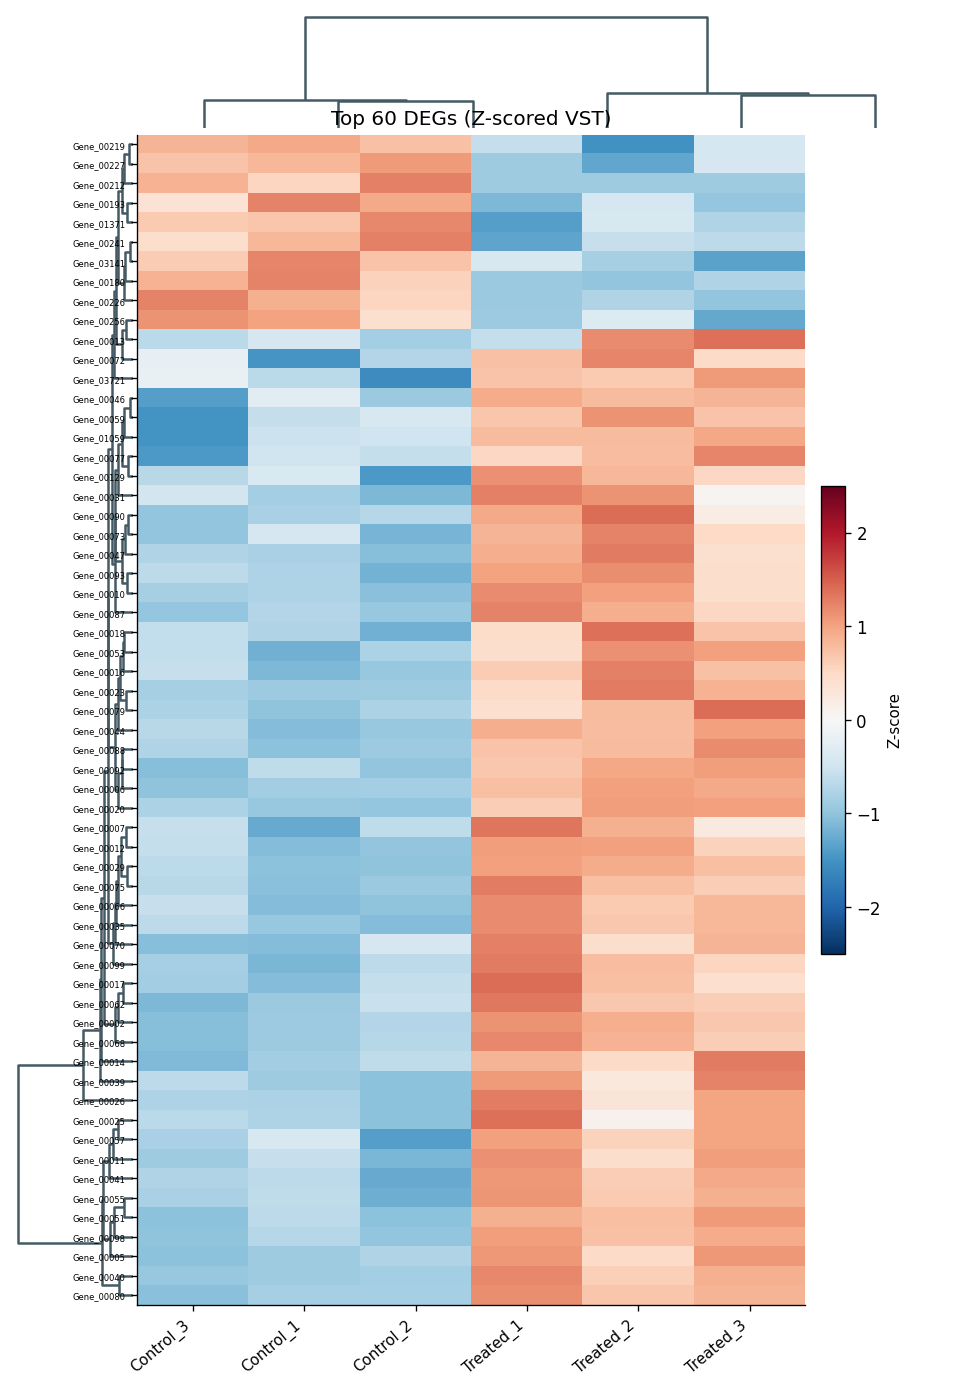

In [28]:
N_TOP = 60   # top N DEGs by adjusted p-value

top_degs = sig.nsmallest(N_TOP, "padj").index.tolist()

# Use VST-normalized values for display
heatmap_data = vst.loc[top_degs]   # shape: (N_TOP genes × samples)

# Z-score across samples (each gene: mean=0, sd=1)
zscored = heatmap_data.subtract(heatmap_data.mean(axis=1), axis=0)
zscored = zscored.divide(heatmap_data.std(axis=1) + 1e-9, axis=0)

# Hierarchical clustering
row_linkage = linkage(zscored.values, method="average", metric="euclidean")
col_linkage = linkage(zscored.T.values, method="average", metric="euclidean")

fig = plt.figure(figsize=(10, 14))
gs  = fig.add_gridspec(2, 2, width_ratios=[0.15, 1], height_ratios=[0.1, 1],
                        hspace=0.01, wspace=0.01)

# Column dendrogram
ax_col = fig.add_subplot(gs[0, 1])
dendrogram(col_linkage, ax=ax_col, orientation="top",
           link_color_func=lambda k: "#455a64")
ax_col.set_axis_off()
col_order = dendrogram(col_linkage, no_plot=True)["leaves"]

# Row dendrogram
ax_row = fig.add_subplot(gs[1, 0])
dendrogram(row_linkage, ax=ax_row, orientation="left",
           link_color_func=lambda k: "#455a64")
ax_row.set_axis_off()
row_order = dendrogram(row_linkage, no_plot=True)["leaves"]

# Heatmap
ax_heat = fig.add_subplot(gs[1, 1])
ordered  = zscored.iloc[row_order, col_order]
im = ax_heat.imshow(ordered.values, aspect="auto", cmap="RdBu_r",
                     vmin=-2.5, vmax=2.5, interpolation="nearest")

ax_heat.set_xticks(range(N_SAMPLES))
ax_heat.set_xticklabels([ordered.columns[i] for i in range(N_SAMPLES)],
                          rotation=40, ha="right", fontsize=9)
ax_heat.set_yticks(range(N_TOP))
ax_heat.set_yticklabels(ordered.index.tolist(), fontsize=5)
ax_heat.set_title(f"Top {N_TOP} DEGs (Z-scored VST)", fontsize=12, pad=6)

cb = plt.colorbar(im, ax=ax_heat, shrink=0.4, pad=0.02)
cb.set_label("Z-score", fontsize=9)

plt.savefig("heatmap_top_degs.png", dpi=150, bbox_inches="tight")
plt.show()

---
## 7. Export results

Save outputs in formats compatible with downstream tools (Enrichr, GSEA, IPA).

In [29]:
# Full results table (all tested genes)
results.to_csv("deseq2_all_results.csv")

# Significant DEGs only
sig.to_csv("deseq2_sig_degs.csv")

# Gene list for Enrichr (just gene symbols, one per line)
sig.index.to_series().to_csv("deg_gene_list.txt", index=False, header=False)

# GSEA pre-ranked format: gene | ranking metric (sign(LFC) * -log10(padj))
rnk = results.copy()
rnk["rank_metric"] = (np.sign(rnk["log2FoldChange"]) *
                      -np.log10(rnk["pvalue"].clip(lower=1e-300)))
rnk[["rank_metric"]].dropna().sort_values("rank_metric", ascending=False).to_csv(
    "gsea_preranked.rnk", sep="\t", header=False
)

print("Saved:")
print("  deseq2_all_results.csv — full results (all genes)")
print("  deseq2_sig_degs.csv    — significant DEGs")
print("  deg_gene_list.txt      — gene list for Enrichr")
print("  gsea_preranked.rnk     — pre-ranked list for GSEA")

Saved:
  deseq2_all_results.csv — full results (all genes)
  deseq2_sig_degs.csv    — significant DEGs
  deg_gene_list.txt      — gene list for Enrichr
  gsea_preranked.rnk     — pre-ranked list for GSEA


---
## 8. Key takeaways

| Decision point | Recommendation | Rationale |
|---|---|---|
| **Count model** | Negative binomial (DESeq2/edgeR) | RNA-Seq counts are overdispersed; NB > Poisson > t-test |
| **Normalization** | Median-of-ratios | Robust to DE genes; accounts for composition bias |
| **Filter threshold** | ≥10 counts in ≥ n_min_group samples | Removes noise; improves multiple-testing correction power |
| **LFC threshold** | \|log2FC\| > 1 (2-fold) | Balances biological and statistical significance |
| **FDR threshold** | padj < 0.05 (BH) | Standard; controls expected proportion of false discoveries |
| **Visualization** | Volcano + MA + heatmap | Volcano: overview; MA: normalization check; heatmap: patterns |
| **Gene ranking for GSEA** | sign(LFC) × −log10(p) | Uses both effect size and significance; avoids arbitrary cutoffs |

### Common mistakes to avoid
- **Never use raw p-values** for genome-wide testing — always correct for multiple comparisons
- **Never log-transform then t-test** on count data with zeroes — pseudocount choice biases results
- **Always check PCA before DE** — a batch effect or sample swap will corrupt all results
- **LFC without shrinkage is noisy** — extremely large/small LFCs often come from low-count genes
